# N04 — Equal-energy preparation geometry

Fix the initial energy and vary only the direction of the state in phase space.  The calculation shows how states on the same energy ellipse can have very different slow- and fast-mode content.

**Question:** how different can the subsequent relaxation be when every initial state has the same energy?


In [1]:
from pathlib import Path
import json, csv, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Locate the project root from the notebook directory or its parents.
def locate_root(start=Path.cwd()):
    candidates = [start, start.parent, start.parent.parent]
    for p in candidates:
        if (p / "experimental_data" / "raw").exists():
            return p.resolve()
    raise FileNotFoundError("Could not locate the project directory containing experimental_data/raw/." )

ROOT = locate_root()
RAW = ROOT / "experimental_data" / "raw"
REF = ROOT / "experimental_data" / "reference"
OUT_DATA = ROOT / "notebook_outputs" / "data"
OUT_FIG = ROOT / "notebook_outputs" / "figures"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

# ---------------- Plot-style switch ----------------
# Safe default: executes everywhere with Matplotlib only.
# Local options:
#   PLOT_STYLE = "science-no-latex"  -> requires `pip install scienceplots`
#   PLOT_STYLE = "science-latex"     -> additionally requires a local LaTeX install
PLOT_STYLE = "matplotlib"

def apply_plot_style(style=PLOT_STYLE):
    plt.style.use("default")
    if style.startswith("science"):
        try:
            import scienceplots  # noqa: F401
            plt.style.use(["science", "no-latex"] if style == "science-no-latex" else ["science"])
        except ImportError:
            warnings.warn("scienceplots is not installed; falling back to Matplotlib.")
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 9.0,
        "axes.labelsize": 9.0,
        "axes.titlesize": 9.5,
        "legend.fontsize": 7.5,
        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.0,
        "axes.linewidth": 0.7,
        "lines.linewidth": 1.3,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    })

apply_plot_style()

# Measured/component values used in the manuscript.
L_H = 44.4e-3
C_F = 454e-6
R_EXT_OHM = 22.2
R_COMP_OHM = 27.9
DETERMINISTIC_RELEASE_S = 7.2e-3

print("Data files located successfully.")
print(f"Plot style: {PLOT_STYLE}")


Data files located successfully.
Plot style: matplotlib


## 1. Dimensionless family with a chosen mode separation

For clarity choose units in which $\lambda_s=-1$ and $\lambda_f=-\rho$. Taking $L=1$, $C=1/\rho$, and $R=1+\rho$ realizes exactly that spectrum.


In [2]:
rho = 10.0   # reader control
L=1.0; C=1.0/rho; R=1.0+rho
A=np.array([[0.,1.],[-1/(L*C),-R/L]])
ls,lf=-1.0,-rho
tau_Es=1/(2*abs(ls))
print(f"lambda_s={ls}, lambda_f={lf}, tau_E,s={tau_Es}")


lambda_s=-1.0, lambda_f=-10.0, tau_E,s=0.5


## 2. Parameterize the fixed-energy ellipse

For $E_0=1$,
$$
q_0=\sqrt{2CE_0}\cos\theta,\qquad
I_0=\sqrt{2E_0/L}\sin\theta.
$$
The pure-mode angles obey $\tan\theta_j=\lambda_j\sqrt{LC}$.


In [3]:
theta=np.linspace(-np.pi/2,np.pi/2,361)
q0=np.sqrt(2*C)*np.cos(theta)
I0=np.sqrt(2/L)*np.sin(theta)
theta_s=np.arctan(ls*np.sqrt(L*C)); theta_f=np.arctan(lf*np.sqrt(L*C))
print(f"slow angle = {np.degrees(theta_s):.2f} deg")
print(f"fast angle = {np.degrees(theta_f):.2f} deg")


slow angle = -17.55 deg
fast angle = -72.45 deg


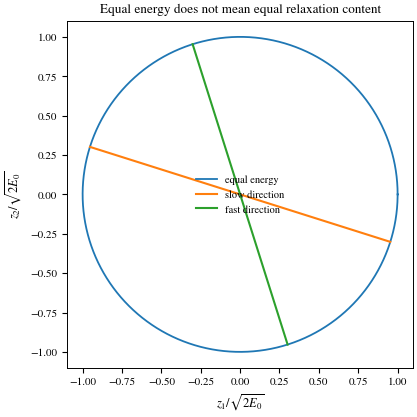

In [4]:
fig,ax=plt.subplots(figsize=(5.0,4.5))
ang=np.linspace(0,2*np.pi,500)
ax.plot(np.cos(ang),np.sin(ang),label="equal energy")
for lam,label in [(ls,"slow"),(lf,"fast")]:
    v=np.array([1/np.sqrt(C),np.sqrt(L)*lam]); v/=np.linalg.norm(v)
    ax.plot([-v[0],v[0]],[-v[1],v[1]],lw=1.5,label=f"{label} direction")
ax.set_aspect("equal"); ax.set_xlabel(r"$z_1/\sqrt{2E_0}$"); ax.set_ylabel(r"$z_2/\sqrt{2E_0}$")
ax.legend(frameon=False); ax.set_title("Equal energy does not mean equal relaxation content")
plt.show()


## 3. Relaxation landscape over preparation angle

The map below shows $E(t)/E_0$ as the angle is varied continuously. The pure fast direction forms a narrow valley because it suppresses the slow spectral component; nearby preparations eventually reveal a slow tail.


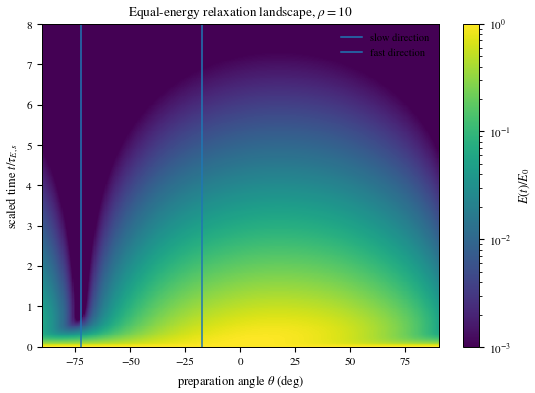

In [5]:
u=np.linspace(0,8,360)     # u=t/tau_Es
X0=np.vstack([q0,I0])
Enorm=np.empty((len(u),len(theta)))
for k,uu in enumerate(u):
    X=expm(A*(uu*tau_Es))@X0
    Enorm[k]=0.5*(X[0]**2/C+L*X[1]**2)

fig,ax=plt.subplots(figsize=(6.4,4.2))
pm=ax.pcolormesh(np.degrees(theta),u,Enorm,shading="auto",norm=mpl.colors.LogNorm(vmin=1e-3,vmax=1))
ax.axvline(np.degrees(theta_s),lw=1.1,label="slow direction")
ax.axvline(np.degrees(theta_f),lw=1.1,label="fast direction")
ax.set_xlabel(r"preparation angle $\theta$ (deg)")
ax.set_ylabel(r"scaled time $t/\tau_{E,s}$")
cb=fig.colorbar(pm,ax=ax); cb.set_label(r"$E(t)/E_0$")
ax.legend(frameon=False); ax.set_title(fr"Equal-energy relaxation landscape, $\rho={rho:g}$")
plt.show()


## 4. Preparation sensitivity near the fast direction

A nominal fast state with current error $\delta I$ contains
$$
c_s=\frac{\delta I}{\lambda_s-\lambda_f}.
$$
The slow-tail energy is therefore quadratic in $\delta I$. The plot below shows the crossover from an initially fast decay to a late slow tail as the error grows.


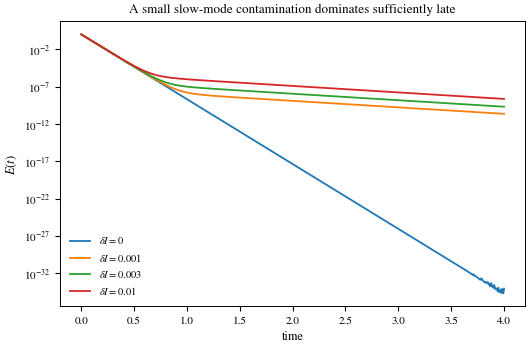

In [6]:
# Fix q0 on the fast line and perturb only I0.
qfast=np.sqrt(2/(1/C+L*lf**2))
Ifast=lf*qfast
deltas=[0,1e-3,3e-3,1e-2]
t=np.linspace(0,4,600)  # dimensionless physical time in this scaling
fig,ax=plt.subplots(figsize=(6.0,3.7))
for dI in deltas:
    x0=np.array([qfast,Ifast+dI])
    vals=[]
    for tt in t:
        x=expm(A*tt)@x0
        vals.append(0.5*(x[0]**2/C+L*x[1]**2))
    ax.semilogy(t,vals,label=fr"$\delta I={dI:g}$")
ax.set_xlabel("time")
ax.set_ylabel(r"$E(t)$")
ax.legend(frameon=False)
ax.set_title("A small slow-mode contamination dominates sufficiently late")
plt.show()


## Reader exercises

- Vary `rho` from 2 to 20 and observe how narrow the fast-relaxation valley becomes.
- Choose two different preparation angles with the same initial energy and locate their crossing numerically.
- Verify that the late slow-tail energy scales quadratically with a small current-preparation error.
